In [73]:
# import needed libraries
from math import *
from joblib import Parallel, delayed
from matplotlib.colors import ListedColormap
import torch
import torch.nn as nn
import torch.optim as optim
import time
import pandas as pd
import seaborn as sns
import numpy as np
import re
import itertools
import random as rd
import matplotlib.pyplot as plt
import plotly.graph_objs as go

In [2]:
# Modelling as MDP 
n_row, n_col = 5, 5
# the states of the system.
n_states, n_actions = n_row*n_col, 4
states = ['s{}'.format(i) for i in range(0, n_states)]

# the possible actions are north, east, south, west i.e., {'N','E','S','W'} 
actions = ['N', 'E', 'S', 'W']

# transitions[s][a]{[s']} = probability of the transition (s, a, {s'})

# these are helper functions to manage the stochastic transitions from a particular state
# and they generates lists used to indicate the successor of a state under an action
# also to make the subsequent declarations more succint
def l3(i, j, k):
    l = [0] * n_states  # Initialize list with zeros
    l[i], l[j], l[k] = 1/3, 1/3, 1/3
    return l

def l2(i, j):
    l = [0] * n_states
    l[i], l[j] = 2/3, 1/3
    return l
# lh for those transitions on the hole state
lh = [[1 if j == i else 0 for j in range(n_states)] for i in range(n_states)]

# now the transition probabilities array depicting the dynamics of the system

transitions = np.array([
    [lh[0], l2(0,5), l2(0,5), l2(0,5)], #0
    [l2(1,2), l3(1,2,6), l3(2,6,1), l2(1,6)], #1
    [lh[2], lh[2], lh[2], lh[2]], #2
    [lh[3], lh[3], lh[3], lh[3]], #3
    [l2(4,3), l2(4,9), l3(4,9,3), l3(4,9,3)], #4
    [l3(0,5,6), l3(0,6,10), l3(6,10,5), l3(0,5,10)], #5
    [l3(1,5,7), l3(1,7,11), l3(5,11,7), l3(1,5,11)], #6
    [l3(6,2,8), l3(2,8,12), l3(8,12,6), l3(12,6,2)], #7
    [l3(7,8,9), l3(8,9,13), l3(9,13,7), l3(13,7,8)], #8
    [l3(8,4,9), l3(4,9,14), l3(9,14,8), l3(14,8,4)], #9
    [l3(5,10,11), l3(5,11,15), l3(10,11,15), l3(15,5,10)], #10
    [l3(10,6,12), l3(6,12,16), l3(12,16,10), l3(16,10,6)], #11
    [l3(11,7,13), l3(7,13,17), l3(13,17,11), l3(17,11,7)], #12
    [l3(12,8,14), l3(8,14,18), l3(14,18,12), l3(18,12,8)], #13
    [l3(13,14,9), l3(13,9,19), l3(19,14,13), l3(13,9,19)], #14
    [l3(10,15,16), l3(10,16,15), l2(15,16), l2(15,10)], #15
    [l3(15,11,17), l3(11,17,21), l3(17,21,15), l3(21,15,11)], #16
    [lh[17], lh[17], lh[17], lh[17]], #17
    [l3(17,13,19), l3(13,19,23), l3(19,23,17), l3(23,17,13)], #18
    [l3(18,14,19), l2(19,14), l2(19,18), l3(19,18,14)], #19
    [l2(20,21), l2(20,21), l2(20,21), lh[20]], #20
    [l3(20,16,22), l3(16,22,21), l3(20,21,22), l3(20,16,21)], #21
    [lh[22], lh[22], lh[22], lh[22]], #22
    [l3(22,18,24), l3(18,24,23), l3(24,23,22), l3(23,22,18)], #23
    [l2(24,23), lh[24], l2(24,23), l2(24,23)], #24
])

In [3]:
def T_lab(next_state):
    label = 'f'
    # labelling function
    if next_state in [2,17,22]:
        label = 'h'
    elif next_state in [3]:
        label = 't'
    elif next_state in [24,20]:
        label = 'm'
    elif next_state in [0,8]:
        label = 'c'
    return label

### Reward machines

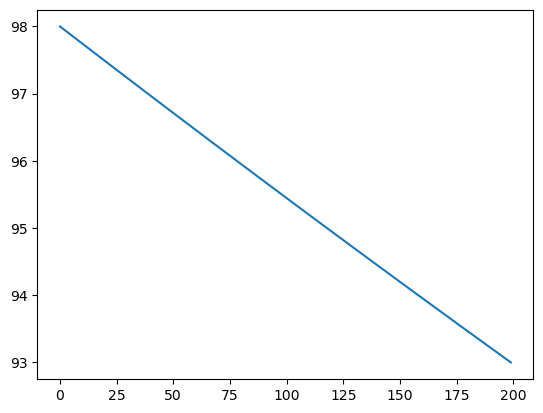

In [4]:
Te, To, ke = 20, 98, .02/60
t=range(200)

def temp(ti):
    return Te + (To - Te)*np.exp(-ke*ti)
    
y = [temp(i) for i in t]
plt.plot(t,y)

In [5]:
y

[98.0,
 97.97400433285189,
 97.94801732948213,
 97.92203898700325,
 97.89606930252879,
 97.87010827317322,
 97.84415589605199,
 97.81821216828148,
 97.79227708697907,
 97.76635064926309,
 97.74043285225281,
 97.7145236930685,
 97.68862316883134,
 97.6627312766635,
 97.6368480136881,
 97.61097337702923,
 97.58510736381191,
 97.55924997116217,
 97.53340119620695,
 97.50756103607416,
 97.4817294878927,
 97.45590654879234,
 97.43009221590391,
 97.40428648635914,
 97.37848935729073,
 97.35270082583233,
 97.32692088911854,
 97.30114954428493,
 97.27538678846801,
 97.24963261880526,
 97.22388703243512,
 97.19815002649693,
 97.17242159813105,
 97.14670174447876,
 97.1209904626823,
 97.09528774988486,
 97.06959360323059,
 97.04390801986456,
 97.01823099693286,
 96.99256253158244,
 96.96690262096126,
 96.94125126221824,
 96.91560845250322,
 96.889974188967,
 96.86434846876132,
 96.83873128903889,
 96.81312264695333,
 96.78752253965928,
 96.76193096431224,
 96.73634791806873,
 96.71077339808616,


In [7]:
Tct = 93
h = .5
# discretized temp
T_h_M = np.arange(Tct, To+h, h)
T_M = (np.around(T_h_M, 2)).tolist() 
T_M

[93.0, 93.5, 94.0, 94.5, 95.0, 95.5, 96.0, 96.5, 97.0, 97.5, 98.0]

In [8]:
Prop = ['c', 'h', 'm', 't']
Urm = [(i, xa) for i, xa in itertools.product(np.array([0,1,2,3,4]), T_M)]
Frm = [(i, xa) for i, xa in itertools.product(np.array([2,4]), T_M)] # terminal states

# state transition and reward function for RS purposes
def temp_v(to):
    tmp = Te + (to - Te)*np.exp(-ke*1)
    for tp in T_M:
        if np.abs(tp-tmp)<=h/2:
            return tp

def delta_v(u, ap):
    q,xt = u
    r,r0,r1,r2 = 0,0,1,0
    if q == 0:
        if (ap != 'c') and (ap != 'h'): q,xt,r = 0,To,r0
        elif (ap == 'c') and (ap != 'h'): q,xt,r = 1,To,r0
        elif (ap == 'h'): q,xt,r = 2,To,r2
        
    elif q == 1:
        if (ap != 'm') and (ap != 'h'): q,xt,r = 1,temp_v(xt),r0
        elif (ap == 'm') and (ap != 'h'): q,xt,r = 3,temp_v(xt),r0
        elif (ap == 'h'): q,xt,r = 2,temp_v(xt),r2
    
    elif q == 3:
        if (ap != 't') and (ap != 'h') and (Tct <= xt <= To): q,xt,r = 3,temp_v(xt),r0
        elif (ap == 't') and (ap != 'h') and (Tct <= xt <= To): q,xt,r = 4,temp_v(xt),r1
        elif (xt < Tct) or (ap == 'h'): q,xt,r = 2,temp_v(xt),r2

    elif q == 4: q,xt,r = 4,xt,r0
        
    elif q == 2: q,xt,r = 2,xt,r2

    return (q,xt), r

In [9]:
discount = 0.9 # Discount factor

### value iteration for RS
def val_it(Urm, epsilon=1e-3):
    V = {u: 0 for u in Urm}
    e = 1    
    while e > (1 - discount) / discount * epsilon:
        e = 0
        for u in [(q, xa) for (q, xa) in Urm if (q, xa) not in Frm]:
            vn = np.max([delta_v(u, sig)[1] + discount * V[delta_v(u, sig)[0]]  for sig in Prop])
            e = np.max([e, np.abs(V[u]-vn)])
            V[u] = vn
    return V

V = val_it(Urm, epsilon=1e-9)

In [10]:
V

{(0, 93.0): 0.81,
 (0, 93.5): 0.81,
 (0, 94.0): 0.81,
 (0, 94.5): 0.81,
 (0, 95.0): 0.81,
 (0, 95.5): 0.81,
 (0, 96.0): 0.81,
 (0, 96.5): 0.81,
 (0, 97.0): 0.81,
 (0, 97.5): 0.81,
 (0, 98.0): 0.81,
 (1, 93.0): 0.9,
 (1, 93.5): 0.9,
 (1, 94.0): 0.9,
 (1, 94.5): 0.9,
 (1, 95.0): 0.9,
 (1, 95.5): 0.9,
 (1, 96.0): 0.9,
 (1, 96.5): 0.9,
 (1, 97.0): 0.9,
 (1, 97.5): 0.9,
 (1, 98.0): 0.9,
 (2, 93.0): 0,
 (2, 93.5): 0,
 (2, 94.0): 0,
 (2, 94.5): 0,
 (2, 95.0): 0,
 (2, 95.5): 0,
 (2, 96.0): 0,
 (2, 96.5): 0,
 (2, 97.0): 0,
 (2, 97.5): 0,
 (2, 98.0): 0,
 (3, 93.0): 1.0,
 (3, 93.5): 1.0,
 (3, 94.0): 1.0,
 (3, 94.5): 1.0,
 (3, 95.0): 1.0,
 (3, 95.5): 1.0,
 (3, 96.0): 1.0,
 (3, 96.5): 1.0,
 (3, 97.0): 1.0,
 (3, 97.5): 1.0,
 (3, 98.0): 1.0,
 (4, 93.0): 0,
 (4, 93.5): 0,
 (4, 94.0): 0,
 (4, 94.5): 0,
 (4, 95.0): 0,
 (4, 95.5): 0,
 (4, 96.0): 0,
 (4, 96.5): 0,
 (4, 97.0): 0,
 (4, 97.5): 0,
 (4, 98.0): 0}

In [88]:
# a description of the simple RM

# state transition and reward function
def delta(u, s, a, s_next, k):
    ap = T_lab(s_next)
    q,xt = u
    r,r0,r1,r2 = 0,0,1,0
    if q == 0:
        if (ap != 'c') and (ap != 'h'): q,xt,r,k = 0,To,r0,k+1
        elif (ap == 'c') and (ap != 'h'): q,xt,r,k = 1,To,r0,0
        elif (ap == 'h'): q,xt,r,k = 2,To,r2,k+1
        
    elif q == 1:
        if (ap != 'm') and (ap != 'h'): q,xt,r,k = 1,temp(k),r0,k+1
        elif (ap == 'm') and (ap != 'h'): q,xt,r,k = 3,temp(k),r0,k+1
        elif (ap == 'h'): q,xt,r,k = 2,temp(k),r2,k+1
    
    elif q == 3:
        if (ap != 't') and (ap != 'h') and (Tct <= xt <= To): q,xt,r,k = 3,temp(k),r0,k+1
        elif (ap == 't') and (ap != 'h') and (Tct <= xt <= To): q,xt,r,k = 4,temp(k),r1,k+1
        elif (xt < Tct) or (ap == 'h'): q,xt,r,k = 2,temp(k),r2,k+1

    elif q == 4: q,xt,r,k = 4,xt,r0,k+1
        
    elif q == 2: q,xt,r,k = 2,xt,r2,k+1

    return (q,xt), r, k

def delta_rs(u, s, a, s_next, k, use_pcrm=False):
    (q,xt), r, k = delta(u, s, a, s_next, k)
    zr, zrn = u[0], q
    rs1 = max(value for key, value in V.items() if key[0] == zr)
    rs1n = max(value for key, value in V.items() if key[0] == zrn)
    dis =  discount * (-rs1n) + rs1
    if use_pcrm: dis=.9*dis
    r = r + dis
    return (q,xt), r, k

In [89]:
# an helper function that provides the possible next states to be sampled from based on an action from a state
def toss(state, action):
    l = []
    lis = transitions[state, action, :]
    for b in range(len(lis)):
        if lis[b] != 0:
            l.append(b)
    next_state = np.random.choice(l)
    return next_state

In [90]:
toss(0,2)

5

In [48]:
# --------------------
# Physics-Informed Neural Network (PINN)
# --------------------
# Define the PINN architecture
class PINN(nn.Module):
    def __init__(self, n_states, n_actions, hidden_size=64):
        super(PINN, self).__init__()
        self.fc1 = nn.Linear(n_states + n_actions, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, n_states)  # Outputs probabilities for all next states
        self.softmax = nn.Softmax(dim=-1)  # Ensure output is a valid probability distribution

    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)  # Concatenate state and action
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.softmax(self.fc3(x))  # Predict probabilities of the next state
        return x

# Helper functions to encode state and action
def one_hot_encode(index, size):
    vec = np.zeros(size)
    vec[index] = 1
    return vec

# Initialize the network
pinn = PINN(n_states, n_actions)
optimizer = optim.Adam(pinn.parameters(), lr=0.001)
loss_fn = nn.MSELoss()  # Loss function

# Example training data
state_idx = 0  # Example: State s0
action_idx = 1  # Example: Action 'E' (east)
next_state_probs = transitions[state_idx, action_idx]  # Ground truth transition probabilities

state = torch.tensor(one_hot_encode(state_idx, n_states), dtype=torch.float32).unsqueeze(0)  # Batch of 1
action = torch.tensor(one_hot_encode(action_idx, n_actions), dtype=torch.float32).unsqueeze(0)

# Convert ground truth probabilities to a tensor
target_probs = torch.tensor(next_state_probs, dtype=torch.float32).unsqueeze(0)

# Training loop
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    output = pinn(state, action)
    loss = loss_fn(output, target_probs)
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

print("Training complete.")

# Example prediction
predicted_probs = pinn(state, action).detach().numpy()
print(f"Predicted probabilities: {predicted_probs}")


Epoch 0, Loss: 0.020369987934827805
Epoch 100, Loss: 4.107565473532304e-05
Epoch 200, Loss: 1.1640886441455223e-05
Epoch 300, Loss: 6.3040806708158925e-06
Epoch 400, Loss: 3.96482892028871e-06
Epoch 500, Loss: 2.7312864858686225e-06
Epoch 600, Loss: 1.999116875595064e-06
Epoch 700, Loss: 1.5276514204742853e-06
Epoch 800, Loss: 1.2054485978296725e-06
Epoch 900, Loss: 9.750426670507295e-07
Training complete.
Predicted probabilities: [[6.6363555e-01 2.6802751e-04 2.7248028e-04 3.3855528e-04 2.0949489e-04
  3.3030331e-01 1.9661612e-04 1.9201556e-04 3.0990891e-04 2.1507901e-04
  2.1721495e-04 2.0435291e-04 2.1132329e-04 1.4278409e-04 3.0091952e-04
  2.7687286e-04 2.0862441e-04 1.6560734e-04 2.6061619e-04 2.7747080e-04
  3.6147604e-04 4.0346553e-04 1.9190389e-04 4.4173730e-04 3.9466235e-04]]


In [49]:
# Function that provides the possible next states to be sampled using the PINN
def toss_pinn(state, action, pinn=pinn, n_states=n_states, n_actions=n_actions):
    """
    Predict the next state using the PINN model.
    
    Args:
        state (int): Current state index.
        action (int): Action index.
        pinn (nn.Module): Trained PINN model.
        n_states (int): Number of states.
        n_actions (int): Number of actions.
    
    Returns:
        int: Predicted next state index.
    """
    # One-hot encode the state and action
    state_vec = torch.tensor(one_hot_encode(state, n_states), dtype=torch.float32).unsqueeze(0)
    action_vec = torch.tensor(one_hot_encode(action, n_actions), dtype=torch.float32).unsqueeze(0)
    
    # Predict the probabilities for the next state
    with torch.no_grad():  # No gradients needed for inference
        next_state_probs = pinn(state_vec, action_vec).squeeze(0).numpy()
    
    # Ensure numerical stability for probabilities
    next_state_probs = np.clip(next_state_probs, 1e-8, 1.0)
    next_state_probs /= next_state_probs.sum()  # Normalize to ensure it sums to 1
    
    # Sample the next state based on the predicted probabilities
    next_state = np.random.choice(np.arange(n_states), p=next_state_probs)
    return next_state

In [50]:
toss_pinn(0,2)

5

In [51]:
# we set up the Mdprm environment as a class
class MdprmEnvironment:
    # we set up a default configuration of the environment
    def __init__(self):
        self.grid_size = 5
        self.num_states = self.grid_size * self.grid_size
        self.num_rm_states = len(Urm)
        self.num_actions = 4 # i.e. action space : (0 for North, 1 for East, 2 for South, and 3 for West)
        
        self.current_state = None
        self.u_t = None
        self.steps = 0
        self.k = 0
        self.max_steps = 200 # beyond this steps, the process is truncated
    
    # we initialize the configuration from any evolved configuration to the default
    def reset(self):
        self.current_state = 15
        self.u_t = (0,To)
        self.steps = 0
        return self.current_state, self.u_t
    
    # takes an action as input and updates the environment accordingly
    def step(self, action, use_rs, use_pcrm, use_pinn=False):
        
        # Store the previous state
        prev_state = self.current_state
        prev_urm = self.u_t
    
        # Update the current state based on the action
        
        if use_pinn:
            s_next = toss_pinn(prev_state, action)
        else:
            s_next = toss(prev_state, action)
        delt = delta(prev_urm, prev_state, action, s_next, self.k)
        if use_rs: delt = delta_rs(prev_urm, prev_state, action, s_next, self.k)
        if use_pcrm: delt = delta_rs(prev_urm, prev_state, action, s_next, self.k, True)
        urm_next = delt[0]
        reward = delt[1]
        self.k = delt[2]
        # handling when a state evolves into a hole or the goal state or there is a need to truncate the evolution
        if T_lab(s_next) == 'h':
            terminated = True
            truncated = False
        elif T_lab(s_next) == 't':
            terminated = False 
            truncated = False
        else:
            terminated = False
            
        truncated = self.steps >= self.max_steps
        
        self.current_state = s_next
        self.u_t = urm_next
        self.steps += 1
        done = terminated or truncated

        # Information dictionary containing some progress information as the process evolves
        info = {
            'previous_state': prev_state, # previous state
            'previous_state_rm': prev_urm, # previous state for RM
            'action': action,             # action taken
            'next_state': s_next,     # the successor
            'next_state_rm': urm_next,     # the successor of RM state
            'episode_reward': reward,     # the accompanying reward 
            'episode_steps': self.steps   # number of steps taken so far
        }
        
        return s_next, urm_next, reward, done, info

    # for pCRM
    def prog(self, S_p, u_bar, action, next_state):
            
        delt = delta_rs(u_bar, S_p, action, next_state, self.k)
        urm_next = delt[0]
        rew_p = delt[1]
        if T_lab(next_state) == 'h':
            terminated = True
            truncated = False
        elif T_lab(next_state) == 't':
            terminated = False 
            truncated = False
        else:
            terminated = False
            
        truncated = self.steps >= self.max_steps
        done_p = truncated or terminated
        return urm_next, rew_p, done_p

In [52]:
### Test the environment ###

env = MdprmEnvironment()

print("Number of states:", env.num_states)
print("Number of RM states:", env.num_rm_states)
print("Number of actions:", env.num_actions)
print("Initial state:", env.reset())
for n in range(5):
    rand_action = np.random.randint(env.num_actions)
    S, Ur, R, done, info = env.step(rand_action, False, False)
    print("  Step", n)
    print("    S =", S)
    print("    Ur =", Ur)
    print("    A =", rand_action)
    print("    R =", R)
    print("    done =", done)
    print(info)
    
    if done:
        break

Number of states: 25
Number of RM states: 55
Number of actions: 4
Initial state: (15, (0, 98))
  Step 0
    S = 10
    Ur = (0, 98)
    A = 0
    R = 0
    done = False
{'previous_state': 15, 'previous_state_rm': (0, 98), 'action': 0, 'next_state': 10, 'next_state_rm': (0, 98), 'episode_reward': 0, 'episode_steps': 1}
  Step 1
    S = 11
    Ur = (0, 98)
    A = 2
    R = 0
    done = False
{'previous_state': 10, 'previous_state_rm': (0, 98), 'action': 2, 'next_state': 11, 'next_state_rm': (0, 98), 'episode_reward': 0, 'episode_steps': 2}
  Step 2
    S = 6
    Ur = (0, 98)
    A = 3
    R = 0
    done = False
{'previous_state': 11, 'previous_state_rm': (0, 98), 'action': 3, 'next_state': 6, 'next_state_rm': (0, 98), 'episode_reward': 0, 'episode_steps': 3}
  Step 3
    S = 7
    Ur = (0, 98)
    A = 0
    R = 0
    done = False
{'previous_state': 6, 'previous_state_rm': (0, 98), 'action': 0, 'next_state': 7, 'next_state_rm': (0, 98), 'episode_reward': 0, 'episode_steps': 4}
  Step 4
 

In [53]:
total_step = 100000 # Number of episodes to learn for

### Q-learning ###
def learn(env,
          use_base_rs=False,
          use_pcrm=False,
          use_pcrm_rs=False,
          use_pinn=False,
          alpha=0.5,  # Learning rate
          epsilon=0.1,  # Exploration rate for epsilon-greedy action selection
          q_init=2.0,  # Initial q-values
          ):
    print_freq = 1000
    # Initialize
    Q = {}
    Avg_reward = []
    epi = []
    step = 0
    rwd_tot = 0
    num_episodes = 0
    use_rs = False
    if use_base_rs or use_pcrm_rs: use_rs = True

    # Learn
    while step < total_step:
        S, Ur = env.reset()
        done = False
        str_key = str((S, Ur))
        if str_key not in Q: Q[str_key] = dict([(ai,q_init) for ai in range(env.num_actions)])
        while True:
            # Pick action epsilon-greedily
            if np.random.rand() < epsilon:
                action = np.random.randint(env.num_actions) # Explore
            else:
                if str((S, Ur)) not in Q:
                    Q[str((S, Ur))] = dict([(ai, q_init) for ai in range(env.num_actions)])
                action = max(Q[str((S, Ur))], key=Q[str((S, Ur))].get)  # Exploit

            # Sample environment
            next_state, next_Ur, reward, done, info = env.step(action, use_rs, use_pcrm, use_pinn)
            # Update Q-table by using Q-learning update rule 
            experiences = []
            B = [(q, xa) for (q, xa) in Urm if (q, xa) not in Frm]
            
            if use_base_rs:
                # experiences = [(S, Ur, action, reward, next_state, next_Ur, done)]
                urm_next, rew_p, done_p = env.prog(S, Ur, action, next_state)
                _s, _ur, _a, _r, _sn, _urn, _done = [S, Ur, action, rew_p, next_state, urm_next, done_p]
                experiences.append((_s, _ur, _a, _r, _sn, _urn, _done))
            
            elif use_pcrm:
                experiences = [(S, Ur, action, reward, next_state, next_Ur, done)]
                urm_next, rew_p, done_p = env.prog(S, Ur, action, next_state)
                experiences.append([S, Ur, action, rew_p, next_state, urm_next, done_p])
                
                # Adding physics-informed counterfactual experience
                for u_bar in B:
                    _s, _ur, _a, _r, _sn, _urn, _done = [S, u_bar, action, delta(u_bar, S, action, next_state, env.k)[1],
                                                        next_state, delta(u_bar, S, action, next_state, env.k)[0], done]
                    experiences.append((_s, _ur, _a, _r, _sn, _urn, _done)) 
                    
                    # ur_p = (u_bar[0], temp(env.k))
                    # Urn_p, rew_p, done_p = env.prog(S, ur_p, action, next_state)
                    # _sp, _urp, _ap, _rp, _snp, _urnp, _donep = [S, ur_p, action, rew_p, next_state, Urn_p, done_p]
                    # experiences.append((_sp, _urp, _ap, _rp, _snp, _urnp, _donep))

            elif use_pcrm_rs:
                # experiences = [(S, Ur, action, reward, next_state, next_Ur, done)]
                # urm_next, rew_p, done_p = env.prog(S, Ur, action, next_state)
                # experiences.append([S, Ur, action, rew_p, next_state, urm_next, done_p])
                # Adding physics-informed counterfactual experience with rs
                for u_bar in B:
                    Urn_p, rew_p, done_p = env.prog(S, u_bar, action, next_state)
                    _sp, _urp, _ap, _rp, _snp, _urnp, _donep = [S, u_bar, action, rew_p, next_state, Urn_p, done_p]
                    experiences.append((_sp, _urp, _ap, _rp, _snp, _urnp, _donep))
                    # ur_p = (u_bar[0], temp(env.k))
                    # Urn_p, rew_p, done_p = env.prog(S, ur_p, action, next_state)
                    # _sp, _urp, _ap, _rp, _snp, _urnp, _donep = [S, ur_p, action, rew_p, next_state, Urn_p, done_p]
                    # experiences.append((_sp, _urp, _ap, _rp, _snp, _urnp, _donep))
                    
            else:
                experiences = [(S, Ur, action, reward, next_state, next_Ur, done)]
                
                            
            for _s, _ur, _a, _r, _sn, _urn, _done in experiences:
                _str_key = str((_s, _ur))
                if _str_key not in Q:
                    Q[_str_key] = dict([(ai, q_init) for ai in range(env.num_actions)])
                _str_keyn = str((_sn, _urn))
                if (_str_keyn not in Q):
                    Q[_str_keyn] = dict([(ai, q_init) for ai in range(env.num_actions)])
                lisp = Q[_str_keyn]
                best_next_action = max(lisp, key=lisp.get)
                dell = _r - Q[_str_key][action]
                if _done:
                    _delta = dell
                else:
                    _delta = dell + discount * Q[str((_sn, _urn))][best_next_action]
                Q[_str_key][action] += alpha * _delta

            rwd_tot += reward
            step += 1
            if step % print_freq == 0:
                av_rwd = rwd_tot
                Avg_reward.append(av_rwd)
                epi.append(num_episodes)
                rwd_tot = 0
            if done:
                num_episodes += 1
                break

            # Move to next state
            S, Ur = next_state, next_Ur

    return Q, Avg_reward, epi


In [22]:
num_keys = 65
RES, RES_rs, RES_pCRM, RES_pCRM_rs = {}, {}, {}, {}
epi, epi_rs, epi_pCRM, epi_pCRM_rs = {}, {}, {}, {}
# for PINNs involved case
RESp, RES_rsp, RES_pCRMp, RES_pCRM_rsp = {}, {}, {}, {}
epip, epi_rsp, epi_pCRMp, epi_pCRM_rsp = {}, {}, {}, {}
def run_learn(use_base_rs=False,use_pcrm=False,use_pcrm_rs=False,use_pinn=False):
    ler = learn(MdprmEnvironment(), use_base_rs, use_pcrm, use_pcrm_rs, use_pinn)
    return ler[1], ler[2]

t1 = time.time()
# Parallelize the learning process
results = Parallel(n_jobs=-1)(delayed(run_learn)(False,False,False) for _ in range(num_keys))
resultsp = Parallel(n_jobs=-1)(delayed(run_learn)(False,False,False,True) for _ in range(num_keys))

# Store the results in dictionaries
RES = {i: results[i][0] for i in range(num_keys)}
epi = {i: results[i][1] for i in range(num_keys)}
RESp = {i: resultsp[i][0] for i in range(num_keys)}
epip = {i: resultsp[i][1] for i in range(num_keys)}

# Get the length of the lists in RES
list_length = len(next(iter(RES.values())))

# Initialize the lists to store the medians
Res_med,Res_av,Res_p25,Res_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_med,eRes_av,eRes_p25,eRes_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

Res_medp,Res_avp,Res_p25p,Res_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_medp,eRes_avp,eRes_p25p,eRes_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median(i):
    lis = [RES[k][i] for k in range(num_keys)]
    elis = [epi[k][i] for k in range(num_keys)]
    lisp = [RESp[k][i] for k in range(num_keys)]
    elisp = [epip[k][i] for k in range(num_keys)]
    return np.median(lis), np.mean(lis), np.percentile(lis, 25), np.percentile(lis, 75),np.median(elis), np.mean(elis), np.percentile(elis, 25), np.percentile(elis, 75), np.median(lisp), np.mean(lisp), np.percentile(lisp, 25), np.percentile(lisp, 75),np.median(elisp), np.mean(elisp), np.percentile(elisp, 25), np.percentile(elisp, 75)


# Parallelize the median computation
medians = Parallel(n_jobs=-1)(delayed(compute_median)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75, medianp, meanp, percentile_25p, percentile_75p, emedianp, emeanp, epercentile_25p, epercentile_75p = stats
    Res_med[i] = median
    Res_av[i] = mean
    Res_p25[i] = percentile_25
    Res_p75[i] = percentile_75
    eRes_med[i] = emedian
    eRes_av[i] = emean
    eRes_p25[i] = epercentile_25
    eRes_p75[i] = epercentile_75
    Res_medp[i] = medianp
    Res_avp[i] = meanp
    Res_p25p[i] = percentile_25p
    Res_p75p[i] = percentile_75p
    eRes_medp[i] = emedianp
    eRes_avp[i] = emeanp
    eRes_p25p[i] = epercentile_25p
    eRes_p75p[i] = epercentile_75p

t2 = time.time()
print(t2-t1)

84.62539219856262


In [25]:
t1 = time.time()
# Parallelize the learning process
results_rs = Parallel(n_jobs=-1)(delayed(run_learn)(True,False,False) for _ in range(num_keys))
results_rsp = Parallel(n_jobs=-1)(delayed(run_learn)(True,False,False,True) for _ in range(num_keys))

# Store the results in dictionaries
RES_rs = {i: results_rs[i][0] for i in range(num_keys)}
epi_rs = {i: results_rs[i][1] for i in range(num_keys)}
RES_rsp = {i: results_rsp[i][0] for i in range(num_keys)}
epi_rsp = {i: results_rsp[i][1] for i in range(num_keys)}

# Initialize the lists to store the medians
Res_rs_med,Res_rs_av,Res_rs_p25,Res_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_rs_med,eRes_rs_av,eRes_rs_p25,eRes_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
Res_rs_medp,Res_rs_avp,Res_rs_p25p,Res_rs_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_rs_medp,eRes_rs_avp,eRes_rs_p25p,eRes_rs_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median_rs(i):
    lis_rs = [RES_rs[k][i] for k in range(num_keys)]
    elis_rs = [epi_rs[k][i] for k in range(num_keys)]
    lis_rsp = [RES_rsp[k][i] for k in range(num_keys)]
    elis_rsp = [epi_rsp[k][i] for k in range(num_keys)]
    return np.median(lis_rs), np.mean(lis_rs), np.percentile(lis_rs, 25), np.percentile(lis_rs, 75), np.median(elis_rs), np.mean(elis_rs), np.percentile(elis_rs, 25), np.percentile(elis_rs, 75), np.median(lis_rsp), np.mean(lis_rsp), np.percentile(lis_rsp, 25), np.percentile(lis_rsp, 75), np.median(elis_rsp), np.mean(elis_rsp), np.percentile(elis_rsp, 25), np.percentile(elis_rsp, 75)


# Parallelize the median computation
medians_rs = Parallel(n_jobs=-1)(delayed(compute_median_rs)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians_rs):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75, medianp, meanp, percentile_25p, percentile_75p, emedianp, emeanp, epercentile_25p, epercentile_75p = stats
    Res_rs_med[i] = median
    Res_rs_av[i] = mean
    Res_rs_p25[i] = percentile_25
    Res_rs_p75[i] = percentile_75
    eRes_rs_med[i] = emedian
    eRes_rs_av[i] = emean
    eRes_rs_p25[i] = epercentile_25
    eRes_rs_p75[i] = epercentile_75
    Res_rs_medp[i] = medianp
    Res_rs_avp[i] = meanp
    Res_rs_p25p[i] = percentile_25p
    Res_rs_p75p[i] = percentile_75p
    eRes_rs_medp[i] = emedianp
    eRes_rs_avp[i] = emeanp
    eRes_rs_p25p[i] = epercentile_25p
    eRes_rs_p75p[i] = epercentile_75p

t2 = time.time()
print(t2-t1)

228.48447608947754


In [91]:
t1 = time.time()
# Parallelize the learning process
results_pcrm = Parallel(n_jobs=-1)(delayed(run_learn)(False,True,False) for _ in range(num_keys))
results_pcrmp = Parallel(n_jobs=-1)(delayed(run_learn)(False,True,False,True) for _ in range(num_keys))

# Store the results in dictionaries
RES_pCRM = {i: results_pcrm[i][0] for i in range(num_keys)}
epi_pCRM = {i: results_pcrm[i][1] for i in range(num_keys)}
RES_pCRMp = {i: results_pcrmp[i][0] for i in range(num_keys)}
epi_pCRMp = {i: results_pcrmp[i][1] for i in range(num_keys)}

# Initialize the lists to store the medians
Res_pcrm_med,Res_pcrm_av,Res_pcrm_p25,Res_pcrm_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_pcrm_med,eRes_pcrm_av,eRes_pcrm_p25,eRes_pcrm_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
Res_pcrm_medp,Res_pcrm_avp,Res_pcrm_p25p,Res_pcrm_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_pcrm_medp,eRes_pcrm_avp,eRes_pcrm_p25p,eRes_pcrm_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median_pcrm(i):
    lis_pcrm = [RES_pCRM[k][i] for k in range(num_keys)]
    elis_pcrm = [epi_pCRM[k][i] for k in range(num_keys)]
    lis_pcrmp = [RES_pCRMp[k][i] for k in range(num_keys)]
    elis_pcrmp = [epi_pCRMp[k][i] for k in range(num_keys)]
    return np.median(lis_pcrm), np.mean(lis_pcrm), np.percentile(lis_pcrm, 25), np.percentile(lis_pcrm, 75), np.median(elis_pcrm), np.mean(elis_pcrm), np.percentile(elis_pcrm, 25), np.percentile(elis_pcrm, 75), np.median(lis_pcrmp), np.mean(lis_pcrmp), np.percentile(lis_pcrmp, 25), np.percentile(lis_pcrmp, 75), np.median(elis_pcrmp), np.mean(elis_pcrmp), np.percentile(elis_pcrmp, 25), np.percentile(elis_pcrmp, 75)


# Parallelize the median computation
medians_pcrm = Parallel(n_jobs=-1)(delayed(compute_median_pcrm)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians_pcrm):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75, medianp, meanp, percentile_25p, percentile_75p, emedianp, emeanp, epercentile_25p, epercentile_75p = stats
    Res_pcrm_med[i] = median
    Res_pcrm_av[i] = mean
    Res_pcrm_p25[i] = percentile_25
    Res_pcrm_p75[i] = percentile_75
    eRes_pcrm_med[i] = emedian
    eRes_pcrm_av[i] = emean
    eRes_pcrm_p25[i] = epercentile_25
    eRes_pcrm_p75[i] = epercentile_75
    Res_pcrm_medp[i] = medianp
    Res_pcrm_avp[i] = meanp
    Res_pcrm_p25p[i] = percentile_25p
    Res_pcrm_p75p[i] = percentile_75p
    eRes_pcrm_medp[i] = emedianp
    eRes_pcrm_avp[i] = emeanp
    eRes_pcrm_p25p[i] = epercentile_25p
    eRes_pcrm_p75p[i] = epercentile_75p

t2 = time.time()
print(t2-t1)

289.9489390850067


In [27]:
t1 = time.time()
# Parallelize the learning process
results_pcrm_rs = Parallel(n_jobs=-1)(delayed(run_learn)(False,False,True) for _ in range(num_keys))
results_pcrm_rsp = Parallel(n_jobs=-1)(delayed(run_learn)(False,False,True,True) for _ in range(num_keys))

# Store the results in dictionaries
RES_pCRM_rs = {i: results_pcrm_rs[i][0] for i in range(num_keys)}
epi_pCRM_rs = {i: results_pcrm_rs[i][1] for i in range(num_keys)}
RES_pCRM_rsp = {i: results_pcrm_rsp[i][0] for i in range(num_keys)}
epi_pCRM_rsp = {i: results_pcrm_rsp[i][1] for i in range(num_keys)}

# Initialize the lists to store the medians
Res_pcrm_rs_med,Res_pcrm_rs_av,Res_pcrm_rs_p25,Res_pcrm_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_pcrm_rs_med,eRes_pcrm_rs_av,eRes_pcrm_rs_p25,eRes_pcrm_rs_p75 = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
Res_pcrm_rs_medp,Res_pcrm_rs_avp,Res_pcrm_rs_p25p,Res_pcrm_rs_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length
eRes_pcrm_rs_medp,eRes_pcrm_rs_avp,eRes_pcrm_rs_p25p,eRes_pcrm_rs_p75p = [0] * list_length,[0] * list_length,[0] * list_length,[0] * list_length

def compute_median_pcrm_rs(i):
    lis_pcrm_rs = [RES_pCRM_rs[k][i] for k in range(num_keys)]
    elis_pcrm_rs = [epi_pCRM_rs[k][i] for k in range(num_keys)]
    lis_pcrm_rsp = [RES_pCRM_rsp[k][i] for k in range(num_keys)]
    elis_pcrm_rsp = [epi_pCRM_rsp[k][i] for k in range(num_keys)]
    return np.median(lis_pcrm_rs), np.mean(lis_pcrm_rs), np.percentile(lis_pcrm_rs, 25), np.percentile(lis_pcrm_rs, 75), np.median(elis_pcrm_rs), np.mean(elis_pcrm_rs), np.percentile(elis_pcrm_rs, 25), np.percentile(elis_pcrm_rs, 75), np.median(lis_pcrm_rsp), np.mean(lis_pcrm_rsp), np.percentile(lis_pcrm_rsp, 25), np.percentile(lis_pcrm_rsp, 75), np.median(elis_pcrm_rsp), np.mean(elis_pcrm_rsp), np.percentile(elis_pcrm_rsp, 25), np.percentile(elis_pcrm_rsp, 75)


# Parallelize the median computation
medians_pcrm_rs = Parallel(n_jobs=-1)(delayed(compute_median_pcrm_rs)(i) for i in range(list_length))

# Unpack the results
for i, stats in enumerate(medians_pcrm_rs):
    median, mean, percentile_25, percentile_75, emedian, emean, epercentile_25, epercentile_75, medianp, meanp, percentile_25p, percentile_75p, emedianp, emeanp, epercentile_25p, epercentile_75p = stats
    Res_pcrm_rs_med[i] = median
    Res_pcrm_rs_av[i] = mean
    Res_pcrm_rs_p25[i] = percentile_25
    Res_pcrm_rs_p75[i] = percentile_75
    eRes_pcrm_rs_med[i] = emedian
    eRes_pcrm_rs_av[i] = emean
    eRes_pcrm_rs_p25[i] = epercentile_25
    eRes_pcrm_rs_p75[i] = epercentile_75
    Res_pcrm_rs_medp[i] = medianp
    Res_pcrm_rs_avp[i] = meanp
    Res_pcrm_rs_p25p[i] = percentile_25p
    Res_pcrm_rs_p75p[i] = percentile_75p
    eRes_pcrm_rs_medp[i] = emedianp
    eRes_pcrm_rs_avp[i] = emeanp
    eRes_pcrm_rs_p25p[i] = epercentile_25p
    eRes_pcrm_rs_p75p[i] = epercentile_75p

t2 = time.time()
print(t2-t1)

1128.9583611488342


In [92]:
# def cumulative_sum(l,p,n=1):
#     l_prime = []
#     for idx, num in enumerate(l):
#         current_sum = sum(l[:idx+1])/(idx+1)
#         l_prime.append(current_sum)
#     lk = l_prime + l[n+1:]
#     return (np.array(lk)/115).tolist()

# def cumulative_sum(l, n=20):
#     cum_avg_list, cum_steps = [], []
#     for i in range(1, len(l) // n + 2):
#         chunk = l[:i * n]
#         avg = sum(chunk) / len(chunk)
#         cum_avg_list.append(avg)
#         cum_steps.append(i*n)
#     return cum_avg_list#, cum_steps

# some post proccesing for rew
def cumulative_sum(l, p, n=1):
    n = min(n, len(l) - 1)
    p_scaled = np.array(p[:n+1]) / max(p[:n+1])
    l_smoothed = [reward * p for reward, p in zip(l[:n+1], p_scaled)]
    lk = l_smoothed + l[n+1:]
    return (np.array(lk)/115).tolist()

# # some post proccesing for rew
# def cumulative_sum(l, p, n=1):
#     n = min(n, len(l) - 1)
#     p_scaled = np.array(p[:n+1]) / max(p[:n+1])
#     l_smoothed = [reward * p for reward, p in zip(l[:n+1], p_scaled)]
#     lk = l_smoothed + l[n+1:]
#     return (np.array(lk)/100).tolist()

n1, n2, n3 = 70, 20, 2
res_med, res_p25, res_p75 = cumulative_sum(Res_med,eRes_med), cumulative_sum(Res_p25,eRes_p25), cumulative_sum(Res_p75,eRes_p75)
res_rs_med, res_rs_p25, res_rs_p75 = cumulative_sum(Res_rs_med,eRes_rs_med,n1), cumulative_sum(Res_rs_p25,eRes_rs_p25,n1), cumulative_sum(Res_rs_p75,eRes_rs_p75,n1)
res_pcrm_med, res_pcrm_p25, res_pcrm_p75 = cumulative_sum(Res_pcrm_med,eRes_pcrm_med,n2), cumulative_sum(Res_pcrm_p25,eRes_pcrm_p25,n2), cumulative_sum(Res_pcrm_p75,eRes_pcrm_p75,n2)
res_pcrm_rs_med, res_pcrm_rs_p25, res_pcrm_rs_p75 = cumulative_sum(Res_pcrm_rs_med,eRes_pcrm_rs_med,n3), cumulative_sum(Res_pcrm_rs_p25,eRes_pcrm_rs_p25,n3), cumulative_sum(Res_pcrm_rs_p75,eRes_pcrm_rs_p75,n3)

In [93]:
n1, n2, n3 = 65, 17, 10
res_medp, res_p25p, res_p75p = cumulative_sum(Res_medp,eRes_medp), cumulative_sum(Res_p25p,eRes_p25p), cumulative_sum(Res_p75p,eRes_p75p)
res_rs_medp, res_rs_p25p, res_rs_p75p = cumulative_sum(Res_rs_medp,eRes_rs_medp,n1), cumulative_sum(Res_rs_p25p,eRes_rs_p25p,n1), cumulative_sum(Res_rs_p75p,eRes_rs_p75p,n1)
res_pcrm_medp, res_pcrm_p25p, res_pcrm_p75p = cumulative_sum(Res_pcrm_medp,eRes_pcrm_medp,n2), cumulative_sum(Res_pcrm_p25p,eRes_pcrm_p25p,n2), cumulative_sum(Res_pcrm_p75p,eRes_pcrm_p75p,n2)
res_pcrm_rs_medp, res_pcrm_rs_p25p, res_pcrm_rs_p75p = cumulative_sum(Res_pcrm_rs_medp,eRes_pcrm_rs_medp,n3), cumulative_sum(Res_pcrm_rs_p25p,eRes_pcrm_rs_p25p,n3), cumulative_sum(Res_pcrm_rs_p75p,eRes_pcrm_rs_p75p,n3)



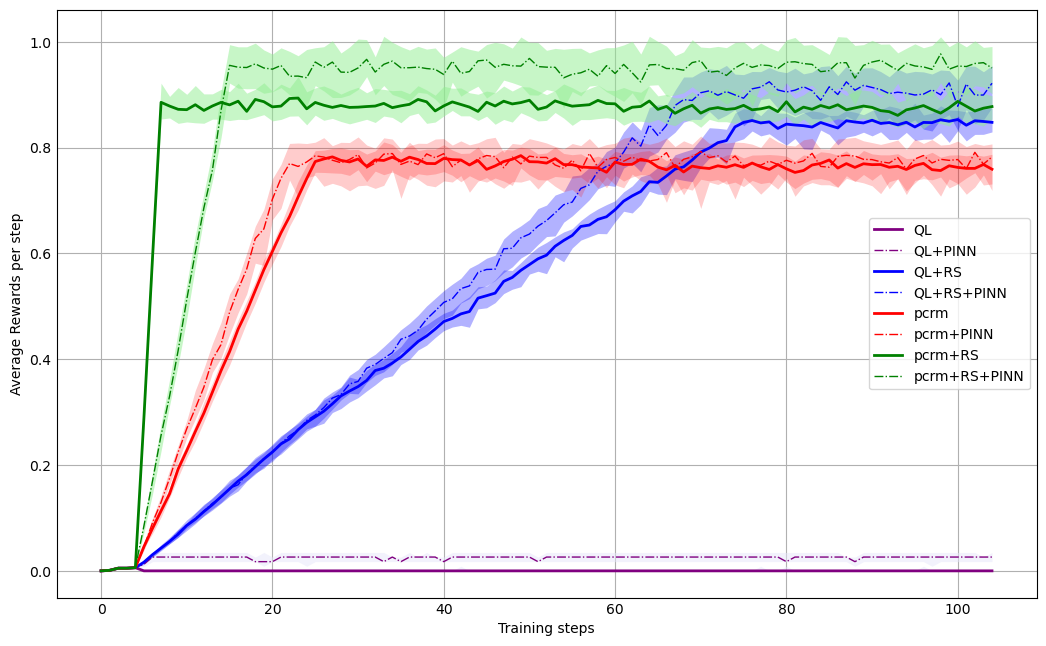

In [94]:
lis = [0,.001,.005,.005,.006]
res_med = lis + res_med
res_rs_med = lis + res_rs_med
res_pcrm_med = lis + res_pcrm_med
res_pcrm_rs_med = lis + res_pcrm_rs_med
res_p25 = lis + res_p25
res_rs_p25 = lis + res_rs_p25
res_pcrm_p25 = lis + res_pcrm_p25 
res_pcrm_rs_p25 = lis + res_pcrm_rs_p25 
res_p75 = lis + res_p75
res_rs_p75 = lis + res_rs_p75
res_pcrm_p75 = lis + res_pcrm_p75 
res_pcrm_rs_p75 = lis + res_pcrm_rs_p75 
xres = range(len(res_med))


res_medp = lis + res_medp
res_rs_medp = lis + res_rs_medp
res_pcrm_medp = lis + res_pcrm_medp
res_pcrm_rs_medp = lis + res_pcrm_rs_medp
res_p25p = lis + res_p25p
res_rs_p25p = lis + res_rs_p25p
res_pcrm_p25p = lis + res_pcrm_p25p
res_pcrm_rs_p25p = lis + res_pcrm_rs_p25p
res_p75p = lis + res_p75p
res_rs_p75p = lis + res_rs_p75p
res_pcrm_p75p = lis + res_pcrm_p75p
res_pcrm_rs_p75p = lis + res_pcrm_rs_p75p

# Set style
plt.style.use('_mpl-gallery')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))  # Set figure size (width, height)

ax.fill_between(xres, res_p25, res_p75, color='Lavender', alpha=.5, linewidth=0)
ax.plot(xres, res_med, color='purple', linewidth=2, label='QL')

ax.fill_between(xres, res_p25p, res_p75p, color='Lavender', alpha=.5, linewidth=0)
ax.plot(xres, res_medp, color='purple', linewidth=1, linestyle='-.', label='QL+PINN')

ax.fill_between(xres, res_rs_p25, res_rs_p75, color='Blue', alpha=.3, linewidth=0)
ax.plot(xres, res_rs_med, color='Blue', linewidth=2, label='QL+RS')

ax.fill_between(xres, res_rs_p25p, res_rs_p75p, color='Blue', alpha=.3, linewidth=0)
ax.plot(xres, res_rs_medp, color='Blue', linewidth=1, linestyle='-.', label='QL+RS+PINN')

ax.fill_between(xres, res_pcrm_p25, res_pcrm_p75, color='red', alpha=.2, linewidth=0)
ax.plot(xres, res_pcrm_med, color='red', linewidth=2, label='pcrm')

ax.fill_between(xres, res_pcrm_p25p, res_pcrm_p75p, color='red', alpha=.2, linewidth=0)
ax.plot(xres, res_pcrm_medp, color='red', linewidth=1, linestyle='-.', label='pcrm+PINN')

ax.fill_between(xres, res_pcrm_rs_p25, res_pcrm_rs_p75, color='lightgreen', alpha=.5, linewidth=0)
ax.plot(xres, res_pcrm_rs_med, color='green', linewidth=2, label='pcrm+RS')

ax.fill_between(xres, res_pcrm_rs_p25p, res_pcrm_rs_p75p, color='lightgreen', alpha=.5, linewidth=0)
ax.plot(xres, res_pcrm_rs_medp, color='green', linewidth=1, linestyle='-.', label='pcrm+RS+PINN')

# Add axis labels
ax.set_xlabel('Training steps')
ax.set_ylabel('Average Rewards per step')

# Add legend
ax.legend(loc='upper left')
plt.show()

In [95]:
# for safe states heatmap
a = learn(MdprmEnvironment(),False,False,False)
ap = learn(MdprmEnvironment(),False,False,False,True)
a_rs = learn(MdprmEnvironment(),True,False,False)
a_rsp = learn(MdprmEnvironment(),True,False,False,True)
a_pcrm = learn(MdprmEnvironment(),False,True,False)
a_pcrmp = learn(MdprmEnvironment(),False,True,False,True)
a_pcrm_rs = learn(MdprmEnvironment(),False,False,True)
a_pcrm_rsp = learn(MdprmEnvironment(),False,False,True,True)

In [106]:
env_grid_size = (n_row, n_col)

def plot_safe_unsafe_heatmap(Q, env_grid_size=env_grid_size, Tct=Tct, h=2):
    """
    Plots a heatmap of safe and unsafe states with varying color intensity 
    based on the max Q value for each state.
    
    Parameters:
        Q (dict): Q-value dictionary with keys as string "(state, (q, xt))" and values as action-value pairs.
        env_grid_size (tuple): The grid size of the environment (rows, cols).
        Tct (float): Threshold for xt to determine safety.
        h (int): Value of q that marks an unsafe state.
    """
    safe_states = np.zeros(env_grid_size)
    state_values = np.zeros(env_grid_size)  # Store the max Q value for each state

    # Populate the heatmap data based on Q
    for key in Q.keys():
        # Parse the key
        state, (q, xt) = eval(key)  # Interpret the string key
        row, col = divmod(state, env_grid_size[1])  # Convert state to grid position

        # Extract the max Q value
        max_q_value = max(Q[key].values())
        state_values[row, col] = max_q_value

        # Classify states based on conditions
        if q != h and xt >= Tct:
            safe_states[row, col] = 1  # Safe state
        else:
            safe_states[row, col] = -1  # Unsafe state

    # Create a colormap where blue represents safe states and red represents unsafe states
    cmap = sns.diverging_palette(240, 10, as_cmap=True)  # Blue for safe, red for unsafe

    # Plotting the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        state_values * safe_states,  # Modulate color intensity by Q value
        cmap="coolwarm_r",#cmap,
        annot=False,
        cbar=True,
        square=True,
        center=0,  # Center around 0 to distinguish safe and unsafe
        cbar_kws={"label": "Max Q Value"}
    )
    # plt.title("Safe and Unsafe States Heatmap (Intensity by Max Q Value)")
    # plt.xlabel("Column")
    # plt.ylabel("Row")
    plt.tight_layout()
    plt.show()


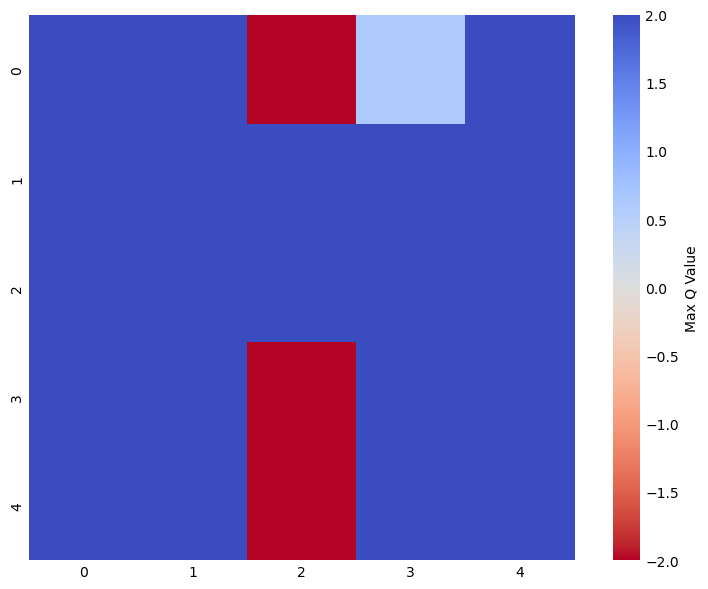

In [107]:
plot_safe_unsafe_heatmap(a[0])

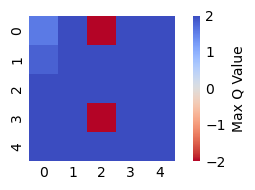

In [98]:
plot_safe_unsafe_heatmap(ap[0])

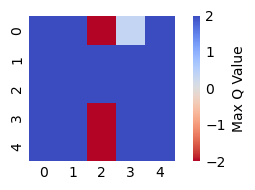

In [99]:
plot_safe_unsafe_heatmap(a_rs[0])

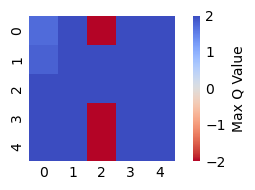

In [100]:
plot_safe_unsafe_heatmap(a_rsp[0])

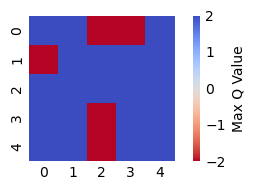

In [102]:
plot_safe_unsafe_heatmap(a_pcrm[0])

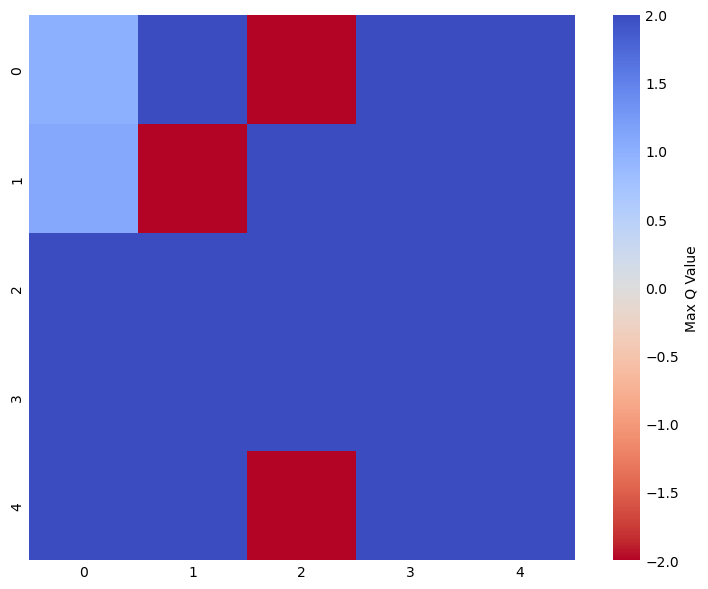

In [108]:
plot_safe_unsafe_heatmap(a_pcrmp[0])

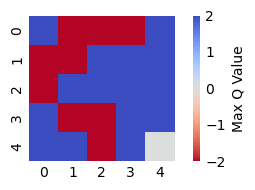

In [104]:
plot_safe_unsafe_heatmap(a_pcrm_rs[0])

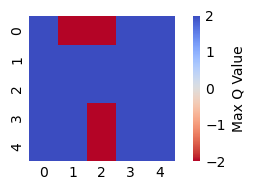

In [105]:
plot_safe_unsafe_heatmap(a_pcrm_rsp[0])